# GRPO (Group Relative Policy Optimization)

As you saw in [RLHF tutorial](./01-rlhf-ppo.ipynb), we finally require a policy model (actor), but value model (critic) is needed during the training to estimate values in PPO algorithm.<br>
GRPO (Group Relative Policy Optimization) is a refined reinforcement algorithm, in which the value model is absent.

In actor-critic method (which is a baseline of PPO algorithm seen in [RLHF tutorial](./01-rlhf-ppo.ipynb)), the policy model (actor) is trained to increase the relative reward score (called "advantage") by using an estimated value in current token, which value is predicted by the value model (critic). After the policy model (actor) is improved, value estimation is also improved by using the refined token sequence as a training set, which sequence is induced by the trained policy model (actor).<br>
In this manner, policy model (actor) and value model (critic) depend on each other, and policy optimization progresses, along with the progress of value estimation.

In GRPO, value estimation is performed without value models (critic). Instead of value estimation by the value model, GRPO uses the average score induced by a group of multiple sampled outputs.

![GRPO conceptual view](./assets/grpo_concept.png)

The absence of value model (the size of which is comparable as the policy model) significantly reduces the memory consumption during training, while the philosophy of advanced RL methodology is retained. (Remind that [DPO](./02-dpo.ipynb) is not a reinforcement learning method, but it trains the preference modeling essentially.)<br>
GRPO also eliminates the complication of actor-critic method - such as, the value estimation at each token. (Usually the reward score is optimally determined by the entire sequence, not individual token. But actor-critic requires the value estimation on individual token.)

---

Now let's briefly see theoretical aspects, along with [[Shao et al., 2024](https://arxiv.org/pdf/2402.03300)].

In GRPO, it requires multiple sampled outputs for each prompt, and I denote the number of samples (in each prompt) as $G$. (The outputs are, therefore, grouped by $G$.)

For value estimation in GRPO, we use the average of reward score in each group (each group has $G$ sampled outputs), instead of using the value estimation induced by value model in PPO.<br>
Now we set the advantage $A_i$ in the output $o_i$ as the normalized reward as follows. :

$\displaystyle A_i = \frac{r_i - \verb|mean|(\{r_1,\ldots,r_G\})}{\verb|std|(\{r_1,\ldots,r_G\})}$

where $r_i$ is the reward at the end of each output $o_i \; (i=1,\ldots,G)$.

> Note : As I have mentioned in [this tutorial](https://github.com/tsmatz/reinforcement-learning-tutorials/blob/master/04-ppo.ipynb), an advantage can often be normalized for stable training in RL.

> Note : As is common in standard statistics and estimation, the standard deviation $\verb|std|(\{r_1,\ldots,r_G\})$ in this equation also applies Bessel's correction. For details, see Chapter 1.2 "Probability theory" (Equation 1.58 and Figure 1.15) in "[Pattern Recognition and Machine Learning](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)" (Christopher M. Bishop, Microsoft).

It's worth noting that here $A_i$ doesn't depend on token position $t$, unlike PPO seen in [RLHF tutorial](./01-rlhf-ppo.ipynb).<br>
In original [GRPO paper](https://arxiv.org/pdf/2402.03300), however, the reward is induced by multiple parts in a sequence, and advantage therefore depends on token position - i.e., $A_{i, t}$. (Later I'll describe the difference between this example and GRPO paper.)

As I have explained in [RLHF tutorial](./01-rlhf-ppo.ipynb) (PPO example), the objective is then to maximize the following expectation.

$\displaystyle \frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \left\{ \min \left[ \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))} A_i, \verb|clip|\left( \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))}, 1-\epsilon, 1+\epsilon \right) A_i \right] - \beta \verb|KL|(\cdot) \right\}$

where

- $|o_i|$ is the number of tokens in the output $o_i$.
- $a_{i,t}$ is a token (i.e., action in RL) at position $t$ in the output $o_i$.
- $s_{i, \lt t}$ is the input sequence (i.e., state in RL) to generate $a_{i,t}$.
- For KL divergence (Kullback–Leibler divergence) term $\verb|KL|(\cdot)$, I'll explain later.
- Both $\epsilon$ and $\beta$ are hyper-parameter for training. (See [RLHF tutorial](./01-rlhf-ppo.ipynb).)

> Note : I use different notation from the one in [[Shao et al., 2024](https://arxiv.org/pdf/2402.03300)]. (I'm using the same notation written in my example, [RLHF tutorial](./01-rlhf-ppo.ipynb).)

As I have written in note in [RLHF tutorial](./01-rlhf-ppo.ipynb), KL term is usually :

$\displaystyle \verb|KL|(P(\cdot | \pi_{\theta_{new}(s)}) \| P(\cdot | \pi_{\theta_{ref}(s)})) = \mathbb{E}_{(s,a)} \left[ \log P(a|\pi_{\theta_{new}}(s)) - \log P(a|\pi_{\theta_{ref}}(s)) \right]$

where $\pi_{\theta_{ref}}(\cdot)$ is a fixed policy during training. (In RLHF, this fixed policy is the policy of supervised trained (SFT) model, $\pi_{\theta_{SFT}}(\cdot)$.)

Now we apply low-variance approximation for KL divergence written in [[John Schulman, 2020](http://joschu.net/blog/kl-approx.html)] as follows. :

$\displaystyle \verb|KL|(P(\cdot | \pi_{\theta_{new}(s)}) \| P(\cdot | \pi_{\theta_{ref}(s)})) = \mathbb{E}_{(s,a)} \left[ \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - \log \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - 1 \right]$

> Note : [[John Schulman, 2020](http://joschu.net/blog/kl-approx.html)] says that original Monte-Carlo approximation of KL divergence has high-variance, and the following approximation preserves low variance instead. :<br>
> $\verb|KL| (q \| p) = (r−1) − \log r$ &nbsp; where $\log r = -\log \frac{q}{p}$.

As a result, our objective is to minimize the following loss $L_{GRPO}$ :

$\displaystyle L_{GRPO} = \frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \left\{ -\min \left[ \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))} A_i, \verb|clip|\left( \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))}, 1-\epsilon, 1+\epsilon \right) A_i \right] + \beta \left( \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - \log \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - 1 \right) \right\}$

![GRPO method compared to PPO](./assets/grpo_method.png)

*From : "[DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/pdf/2402.03300)" [Shao et al., 2024]*

In [RLHF paper](https://arxiv.org/pdf/2203.02155), the reference policy $\pi_{\theta_{ref}}(\cdot)$ is a fixed policy (as a supervised trained (SFT) model, $\pi_{\theta_{SFT}}(\cdot)$) during training, because the objective of training is to align human preference, in which the generated policy will not be so far from original policy, $\pi_{\theta_{ref}}(\cdot)$. In [GRPO paper](https://arxiv.org/pdf/2402.03300), however, the objective of training is to significantly improve the reasoning capabilities, which will eventually lead to a largely updated policy. The policy $\pi_{\theta_{ref}}(\cdot)$ is, therefore, constanly updated (replaced) by the current policy, $\pi_{\theta_{new}}(\cdot)$.<br>
In this example, we apply latter approach.

> Note : Later I will change the loss normalization from this original one. (I'll describe later.)

---

Now let's see the code (implementation) step-by-step.

In original paper [[Shao et al., 2024](https://arxiv.org/pdf/2402.03300)], GRPO is applied to generate a reasoning model for training the highly-skilled reasoning abilities, but in this example, we simply apply GRPO to get humanity seen in [RLHF tutorial](./01-rlhf-ppo.ipynb). (It's roughly the same as [RLHF tutorial](./01-rlhf-ppo.ipynb), but we just apply GRPO instead of PPO in RL phase.)<br>
Several optimizations (as follows) made specifically to gain reasoning capabilities in [[Shao et al., 2024](https://arxiv.org/pdf/2402.03300)] are then skipped in this example. I'll focus on the algorithm of GRPO in this example.

- In GRPO paper, the advantage $A_i$ depends not only on a reward score in the last token, but it's induced by multiple parts of reward scores in a sequence with backwards causation (retrocausality), because it's for evaluating the reasoning steps more granularly. (For details, see chapter 4.1.3 "Process Supervision" in the [paper](https://arxiv.org/pdf/2402.03300).) In this example, we don't apply this strategy (process supervision), but apply ordinary one (outcome supervision) based only on a reward score in the last token.
- In GRPO paper, a reward model is constantly updated (replay mechanism) during RL training. (See chapter 4.1.4 in the paper.) In this example, we don't also apply this strategy (replay mechanism), but we use a fixed trained reward model during RL training.

Throughout this notebook, I have used pretrained model in Hugging Face, but **I manually configure and run training with regular PyTorch training loop** (i.e., won't use any built-in class in Hugging Face) not to make the implementation black-boxed.

*(back to [index](https://github.com/tsmatz/reinforcement-learning-in-llm/))*

## Prerequisites

Before we start, we need to install the required packages.

In [ ]:
!pip install torch transformers datasets matplotlib

## Prepare Dataset

Before training, we should prepare (preprocess) the training dataset.

In this example, we use dataset, [Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), for training.

In [1]:
from datasets import load_dataset

all_data = load_dataset("HumanLLMs/Human-Like-DPO-Dataset")
train_data = all_data["train"]
train_data

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 10884
})

This dataset has 2 labels, "```chosen```" and "```rejected```", which is respectively a preferred response (i.e., more natural and informal response) and a non-preferred response.

In [2]:
row_num = 0
print("********** prompt **********")
print(train_data["prompt"][row_num])
print("********** chosen **********")
print(train_data["chosen"][row_num])
print("********** rejected **********")
print(train_data["rejected"][row_num])
print("********** end **********")

********** prompt **********
Oh, I just saw the best meme - have you seen it?
********** chosen **********
😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣
********** rejected **********
I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?
********** end **********


Now we convert this data into the following text format, fitting for SmolLM2-Instruct inputs.<br>
In this format, the user role in chat message is "```<|im_start|>user\n...<|im_end|>```" and the assistant role in chat message is "```<|im_start|>assistant\n...<|im_end|>```".

```
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant
😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>
```

> Note : If you want to include system role, use "```<|im_start|>system\n...<|im_end|>```".

In [3]:
def format_to_chatml(example):
    return {
        "chosen": f"<|im_start|>user\n{example["prompt"]}<|im_end|>\n<|im_start|>assistant\n{example["chosen"]}<|im_end|>",
        "rejected": f"<|im_start|>user\n{example["prompt"]}<|im_end|>\n<|im_start|>assistant\n{example["rejected"]}<|im_end|>",
    }

original_columns = train_data.column_names
train_data = train_data.map(format_to_chatml, remove_columns=original_columns)

In [4]:
row_num = 0
print("********** chosen **********")
print(train_data["chosen"][row_num])
print("********** rejected **********")
print(train_data["rejected"][row_num])
print("********** end **********")

********** chosen **********
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant
😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>
********** rejected **********
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant
I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>
********** end **********


In order to reduce memory consumption (prevent from GPU out of memory errors), we now filter data not to exceed a certain length of tokens.

In [5]:
from transformers import AutoTokenizer

base_model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"

# download tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

In [6]:
max_seq_len = 768

# 1. add "chosen_len" and "rejected_len" column
#   (which indicates the sequence length in "chosen" and "rejected")
def add_seq_len(example):
    def get_tokenized_length(text):
        tokenized = tokenizer(text)
        return len(tokenized["input_ids"])

    chosen_len = get_tokenized_length(example["chosen"])
    reject_len = get_tokenized_length(example["rejected"])
    return {
        "chosen_len": chosen_len,
        "rejected_len": reject_len
    }

train_data = train_data.map(add_seq_len)

# 2. remove rows which exceed the maximum sequence length
train_data = train_data.filter(lambda example: example["chosen_len"] <= max_seq_len and example["rejected_len"] <= max_seq_len)
train_data = train_data.remove_columns(["chosen_len", "rejected_len"])

# show total number of filtered rows
train_data

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 10820
})

## Step 1 : Run Supervised Fine-tuning (SFT)

Same as in [RLHF example](./01-rlhf-ppo.ipynb), we firstly apply SFT (Supervised Fine-tuning) using good samples ("chosen" tokens).

This phase is completely same as one in [RLHF example](./01-rlhf-ppo.ipynb), so **please run step1 in [RLHF example](./01-rlhf-ppo.ipynb) to get a SFT model**.<br>
(The model checkpoint is saved on ```./llm_sft``` folder.)

In [ ]:
#### Run step 1 in 01-rlhf-ppo.ipynb

Load trained SFT model as $\pi_{\theta_{new}}$ and $\pi_{\theta_{ref}}$.<br>
The model $\pi_{\theta_{new}}$ is a baseline (startpoint) for RL training.

In [7]:
import torch

device = torch.device("cuda")
torch.set_default_dtype(torch.bfloat16) # because SmolLM2-Instruct is trained on bf16

In [8]:
from transformers import AutoModelForCausalLM

pi_new = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)
pi_ref = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)

for p in pi_ref.parameters():  # freeze all parameters in pi_ref
    p.requires_grad = False

## Step 2 : Build a reward model

Next we should build a reward model.

This phase is also completely same as one in [RLHF example](./01-rlhf-ppo.ipynb), so **please run step2 in [RLHF example](./01-rlhf-ppo.ipynb) to get a reward model**.<br>
(The model checkpoint is saved as ```./rm.pt```.)

In [ ]:
#### Run step 2 in 01-rlhf-ppo.ipynb

Load trained reward model (RM).

In [9]:
from torch import nn

# define model class (see RLHF tutorial)
class RewardModel(nn.Module):
    def __init__(
        self,
        base_model,
    ):
        super().__init__()

        # replace final linear layer
        self.base_model = base_model
        self.base_model.__setattr__(
            "lm_head",
            nn.Linear(576, 1, bias=False).to(device))

    def forward(self, input_ids, attention_mask):
        output = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits

        # need only final output in sequence
        batch_size = input_ids.shape[0]
        token_indices = torch.arange(input_ids.shape[-1], dtype=int).to(device)
        last_nonpad_indices = (token_indices * attention_mask).argmax(-1)
        reward_score = output[torch.arange(batch_size).to(device), last_nonpad_indices]

        return reward_score

# generate model instance
base_model = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)
rm = RewardModel(base_model).to(device)

In [10]:
rm.load_state_dict(torch.load("rm.pt", weights_only=True))

<All keys matched successfully>

## Step 3 : Reward Training with GRPO

Now, train a SFT model with RL to gain the object ability (humanity, in this example).<br>
In this notebook, we'll apply GRPO instead of PPO.

### 1. Build a function to generate samples

First we build a function to generate samples (sample tokens) with current policy (i.e., current language model).

As you saw above, GRPO requires $G$ samples in each context, and **$G$ samples are then generated** in each context in this function. ($G$ is ```num_generations``` in the following function.)<br>
Other parts are mostly same as one in [RLHF tutorial](./01-rlhf-ppo.ipynb).

In this example, we simply use greedy sampling (use more huristic search algorithms in practice - such as, beam search), and also we use **attention cache** for sequential token generation to speed up.

In [11]:
from torch.nn import functional as F
from transformers import DynamicCache

def generate_token_by_policy(
    context,
    model,
    tokenizer,
    max_seq_len,
    num_generations=1,
):
    """
    Collect samples with a model (LLM) as a batch.
    To speed up generation, here we use attention cache.
    All tensors are collected with no gradient (as detached tensors).

    Parameters
    ----------
    context : dic(
            input_ids: torch.tensor((batch_size, seq_len), dtype=int),
            attention_mask: torch.tensor((batch_size, seq_len), dtype=int)
        )
        Chat template data to be fed as a batch.
        The format should be left-side padding, and shouldn't include the
        final assistant's message, because it'll be generated in this function.
        (The length of input's sequence (seq_len) might differ in each call.)
    model : torch.nn.Module
        A model which is used to pick up an action (i.e., a token).
        In this function, the output is generated with no gradient.
    tokenizer : transformers.PreTrainedTokenizer
        Hugging Face tokenizer class to be used in this model.
    max_seq_len : int
        Maximum sequence length. (See above description.)
    num_generations : int
        The number of sample generation for each context (i.e., G).
        The output size on dimension 0 will then become batch_size * num_generations.

    Returns
    ----------
    completion_ids : torch.tensor((batch_size*num_generations, seq_len), dtype=int)
        The array of token id for generated chat completion (including context tokens).
        The length of result's sequence (i.e., seq_len) differs depending
        on the results.
    completion_mask : torch.tensor((batch_size*num_generations, seq_len), dtype=int)
        Corresponding attention mask.
    """

    # repeat inputs, num_generations times
    cur_iids = context["input_ids"].repeat_interleave(num_generations, dim=0)
    cur_mask = context["attention_mask"].repeat_interleave(num_generations, dim=0)

    # get output's batch size
    output_batch_size = cur_iids.shape[0]

    # initialize a flag for processing/finish in a batch
    # (True: processing, False: finished)
    proceed_flag = torch.ones(output_batch_size, dtype=bool).to(device)

    # initialize cache parameters
    cache_position = None
    past_key_values = DynamicCache()

    # loop until all is done
    done_tokens_num = 0
    while(torch.any(proceed_flag)):
        # get current sequence length
        cur_seq_len = cur_iids.shape[1]

        # get the final non-pad token indices in sequence
        # --> shape:[output_batch_size]
        token_indices = torch.arange(cur_seq_len, dtype=int).to(device)
        last_nonpad_indices = (token_indices * cur_mask).argmax(-1)

        # run inference (with no gradient !)
        if cache_position is None:
            # get initial cache position
            cache_position = torch.arange(cur_seq_len, dtype=int, device=device)
            # compute logits for all input_ids
            logits = model(
                input_ids=cur_iids,
                attention_mask=cur_mask,
                cache_position=cache_position,
                past_key_values=past_key_values,
                use_cache=True,
            ).logits.detach()
            # need only final output in sequence --> shape:[output_batch_size, vocab_size]
            logits = logits[torch.arange(output_batch_size).to(device), last_nonpad_indices, :]
        else:
            # compute logits only for the last input_ids
            # (others are all cached.)
            logits = model(
                input_ids=cur_iids[:,-1:],
                attention_mask=cur_mask,
                cache_position=cache_position,
                past_key_values=past_key_values,
                use_cache=True,
            ).logits.detach()
            # reshape to [output_batch_size, vocab_size]
            logits = logits.squeeze(1)

        # select a token (i.e., take an action)
        # --> shape:[output_batch_size]
        probs = F.softmax(logits, dim=-1)
        selected_ids = torch.multinomial(probs, num_samples=1).squeeze(-1)

        # get next token indices in sequence
        # --> shape:[output_batch_size]
        next_token_indices = last_nonpad_indices + proceed_flag.int()

        # expand inputs when it exceeds
        # --> shape:[output_batch_size, cur_seq_len+1]
        if next_token_indices.max() > cur_seq_len - 1:
            cur_iids = F.pad(input=cur_iids, pad=(0, 1, 0, 0), mode="constant", value=tokenizer.pad_token_id)
            cur_mask = F.pad(input=cur_mask, pad=(0, 1, 0, 0), mode="constant", value=0)

        # store new token ids
        cur_iids[proceed_flag, next_token_indices[proceed_flag]] = selected_ids[proceed_flag]

        # store new attention mask
        cur_mask[proceed_flag, next_token_indices[proceed_flag]] = 1

        # update cache_position
        cache_position = cache_position[-1:] + 1

        # update proceed_flag
        not_lim = (cur_mask.sum(dim=1) < max_seq_len)
        is_eos = torch.logical_and((selected_ids == tokenizer.eos_token_id),proceed_flag.bool())
        not_eos = torch.logical_not(is_eos)
        proceed_flag = torch.logical_and(proceed_flag, torch.logical_and(not_lim, not_eos))

    return cur_iids, cur_mask

### 2. Configure hyper-parameters

Now I set the hyper-parameters for GRPO training.

In this example, I seperate entire process into generation phase (in which, no gradient is required) and training phase.<br>
In generation phase, the model outputs are collected (As I described above, $G$ samples are generated in each context) and the advantage $A_i$ is computed in each group.<br>
In training phase, all collected outputs (and advantages) are separated into mini-batch, and the gradient accumulation training is applied, in order to reduce the resource's consumption.

In respective phase, I set the following parameters. (See below picture.)

![Generation phase](./assets/grpo_gen_phase.png)

![Training phase](./assets/grpo_train_phase.png)

In [12]:
### generation parameters
context_batch_size = 6            # number of context in each generation
G = 8                             # number of samples to generate in each context

### training parameters
train_batch_size = 4              # mini-batch size to compute gradient
# gradient_accumulation_steps = context_batch_size * G / train_batch_size

In [13]:
assert((context_batch_size * G) % train_batch_size == 0)

### 3. Build dataset and loader for RL

We create a dataset for trainer.<br>
In this training, the final message (the reply message of assistant's role) is not required, and we then remove the final reply message in the sequence.

In [14]:
# remove the final message,
# but it keeps the final "<|assistant|>\n"
def rm_fin_msg(chat_str):
    target = "<|im_start|>assistant\n"
    start_idx = chat_str.rfind(target)
    return chat_str[:(start_idx + len(target))]

In [15]:
for row in range(3):
    print("********** original chat **********")
    print(train_data["chosen"][row])
    print("********** converted chat **********")
    print(rm_fin_msg(train_data["chosen"][row]))

********** original chat **********
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant
😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>
********** converted chat **********
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant

********** original chat **********
<|im_start|>user
Do you have a go-to karaoke jam?<|im_end|>
<|im_start|>assistant
Oh, totally! 😄 I'm a sucker for a good ol' rock ballad. Give me some Bon Jovi any day of the week! "Livin' on a Prayer" is my go-to karaoke jam. There's just something about belting out "Oh, we're halfway there!" at the top of my lungs that gets me pumped up! 🎤 What about you, do you have a favorite karaoke song? 🎶<|im_end|>
********** converted chat **********
<|im_start|>user
Do you have a go-to karaoke jam?<|im_end|>
<|im_start|>assistant

********** original chat ****

In [16]:
from torch.utils.data import DataLoader

# In order to use caching (for speed-up),
# we need left-side padding in the training batch.
def collate_batch(batch):
    # remove the final message
    chat_list = [rm_fin_msg(item["chosen"]) for item in batch]

    # tokenize (convert to token ids and attention mask) and convert to tensor
    chat_tensor = tokenizer(
        chat_list,
        padding=True,
        padding_side="left",
        return_tensors="pt").to(device)
    return chat_tensor

dataloader = DataLoader(
    train_data,
    batch_size=context_batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

### 4. Train with GRPO

Now let's train a policy model with GRPO.<br>
As we saw above, our objective is to minimize the following loss, $L_{GRPO}$. :

$\displaystyle L_{GRPO} = \frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \left\{ -\min \left[ \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))} A_i, \verb|clip|\left( \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))}, 1-\epsilon, 1+\epsilon \right) A_i \right] + \beta \left( \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - \log \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - 1 \right) \right\}$

$\displaystyle A_i = \frac{r_i - \verb|mean|(\{r_1,\ldots,r_G\})}{\verb|std|(\{r_1,\ldots,r_G\})}$

where $r_i$ is the reward at the end of each output $o_i \; (i=1,\ldots,G)$.

However, the term $\frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|}$ results in shorter responses being highly weighted in gradient descent optimization.<br>
To address this concern, in this example, we apply **token-level loss normalization** (which is adopted in recent algorithms - such as, DAPO, CISPO, ...) as follows, instead.

$\displaystyle L_{GRPO} = \frac{1}{\sum_{i=1}^G |o_i|} \sum_{i=1}^G \sum_{t=1}^{|o_i|} \left\{ -\min \left[ \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))} A_i, \verb|clip|\left( \frac{P(a_{i,t}|\pi_{\theta_{new}}(s_{i, \lt t}))}{P(a_{i,t}|\pi_{\theta_{old}}(s_{i, \lt t}))}, 1-\epsilon, 1+\epsilon \right) A_i \right] + \beta \left( \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - \log \frac{P(a | \pi_{\theta_{ref}(s)})}{P(a | \pi_{\theta_{new}(s)})} - 1 \right) \right\}$

In [RLHF tutorial](./01-rlhf-ppo.ipynb), we have applied linear warmup in the training, because we wait until value model is trained enough.<br>
In this training, however, we don't need linear warmup any more, because we don't use value model.

> Note : In categorical disribution, the log probability $\log P(a)$ can be derived by the negative value of cross-entropy error - i.e., ```-torch.nn.functional.cross_entropy(l, a)```, where ```l``` is logits and ```a``` is a taken action (i.e., a selected token).

In [17]:
import math
from torch.optim.lr_scheduler import LambdaLR
import functools

num_epochs = 1
num_train_update = len(dataloader)

# create optimizer
optimizer = torch.optim.AdamW(
    params=pi_new.parameters(),
    lr=3.0e-5,
    betas=(0.9, 0.999),
    eps=1e-08,
)

# create scheduler
def _get_cosine_schedule(
    current_step: int,
    num_training_steps: int,
    num_warmup_steps: int=0,
    linear_warmup: bool=False,
    min_value: float=0.0,
):
    if current_step < num_warmup_steps:
        if linear_warmup:
            return min(1.0, (current_step + 1) / (num_warmup_steps + 1))  # see https://arxiv.org/abs/2410.11020
        else:
            return 1.0
    progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
    scale = 0.5 * (1.0 + math.cos(math.pi * progress))
    return (1.0 - min_value) * scale + min_value

scheduler = LambdaLR(optimizer, lr_lambda=functools.partial(
    _get_cosine_schedule,
    num_training_steps=num_epochs*num_train_update,
    num_warmup_steps=math.ceil(num_epochs*num_train_update*0.1)))

In [18]:
import os

beta = 0.05    # beta (KL coefficient)
epsilon = 0.2  # epsilon (paramter for clipping policy)

M = 50         # pi_ref is replaced with pi_new every M updates

# remove log file if exists
log_file = "reward.log"
if os.path.exists(log_file):
    os.remove(log_file)

# reward model and reference model is always for inference
rm.eval()
pi_ref.eval()

# iterate epoch
for epoch in range(num_epochs):
    optimizer.zero_grad()
    reward_current = 0.0
    record_reward = []

    # iterate data by batch
    for i, chat in enumerate(dataloader):
        input_seq_len = chat["input_ids"].shape[1]

        ##########
        ##########
        ### Generation Phase
        ##########
        ##########

        print(f"Epoch {epoch+1} {i+1}/{num_train_update} - reward {reward_current :5.4f} sampling ....", end="\r")
        pi_new.eval()
        with torch.no_grad():
            # generate tokens with current policy
            # (G samples are generated in each context)
            # context_batch_size * G / train_batch_size
            gen_iids, gen_mask = generate_token_by_policy(
                chat,
                pi_new,
                tokenizer,
                max_seq_len,
                G,
            )
            batch_size_actual = gen_iids.shape[0]

            # mask only inference (pred) tokens
            seq_len = gen_iids.shape[1]
            token_indices = torch.arange(seq_len, dtype=int).to(device)
            inf_mask = gen_mask * (token_indices >= input_seq_len).int()

            # pad left
            # (e.g., [[0,1,1,0,0,],[1,1,1,1,0]] --> [[0,0,0,1,1],[0,1,1,1,1]])
            last_nonpad_indices = (token_indices * gen_mask).argmax(-1)
            for b in range(batch_size_actual):
                gen_iids[b,:] = torch.roll(
                    gen_iids[b,:],
                    shifts=(seq_len - last_nonpad_indices[b] - 1).item()
                )
                gen_mask[b,:] = torch.roll(
                    gen_mask[b,:],
                    shifts=(seq_len - last_nonpad_indices[b] - 1).item()
                )
                inf_mask[b,:] = torch.roll(
                    inf_mask[b,:],
                    shifts=(seq_len - last_nonpad_indices[b] - 1).item()
                )

            # the final state is not used for estimation
            inf_mask = inf_mask[:,:-1]

            # get rewards
            seq_rewards = rm(
                input_ids=gen_iids,
                attention_mask=gen_mask,
            ).detach().squeeze(-1).float()
            reward_current = seq_rewards.mean().item()
            record_reward.append(reward_current)

            # compute advantage (A_i)
            reward_std = seq_rewards.view(-1, G).std(dim=1)  # include Bessel's correction (see above note)
            reward_std = reward_std.repeat_interleave(G, dim=0)
            reward_mean = seq_rewards.view(-1, G).mean(dim=1)
            reward_mean = reward_mean.repeat_interleave(G, dim=0)
            adv = torch.where(
                reward_std == 0.0,
                0.0,
                (seq_rewards - reward_mean) / reward_std)

            # only the completed sequence is processed
            is_eos = torch.logical_and(gen_iids[:,-1] == tokenizer.eos_token_id, inf_mask.sum(-1) > 0)
            is_eos_num = is_eos.int().sum()
            if is_eos_num == 0:
                continue
            elif not(is_eos_num == batch_size_actual):
                gen_iids = gen_iids[is_eos]
                gen_mask = gen_mask[is_eos]
                inf_mask = inf_mask[is_eos]
                adv = adv[is_eos]
                batch_size_actual = is_eos_num

        ##########
        ##########
        ### Training Phase
        ##########
        ##########

        print(f"Epoch {epoch+1} {i+1}/{num_train_update} - reward {reward_current :5.4f} updating ....", end="\r")
        pi_new.train()
        with torch.set_grad_enabled(True):
            for cur_batch_idx in range(0, batch_size_actual, train_batch_size):
                # pick up train batch
                train_gen_iids = gen_iids[cur_batch_idx:cur_batch_idx+train_batch_size]
                train_gen_mask = gen_mask[cur_batch_idx:cur_batch_idx+train_batch_size]
                train_inf_mask = inf_mask[cur_batch_idx:cur_batch_idx+train_batch_size]
                train_adv = adv[cur_batch_idx:cur_batch_idx+train_batch_size]

                # trim left to reduce computation
                # (e.g., [[0,0,0,1,1],[0,1,1,1,1]] --> [[0,0,1,1],[1,1,1,1]])
                seq_len = train_gen_iids.shape[1]
                token_indices = torch.arange(seq_len, dtype=int).to(device)
                first_nonpad_indices = (torch.flip(token_indices, dims=(0,)) * train_gen_mask).argmax(-1)
                start_index = first_nonpad_indices.min()
                train_gen_iids = train_gen_iids[:,start_index:]
                train_gen_mask = train_gen_mask[:,start_index:]
                train_inf_mask = train_inf_mask[:,start_index:]

                # get logits
                logits_new = pi_new(
                    input_ids=train_gen_iids[:,:-1],
                    attention_mask=train_gen_mask[:,:-1],
                )
                logits_new = logits_new.logits.float()
                logits_old = logits_new.detach()

                logits_ref = pi_ref(
                    input_ids=train_gen_iids[:,:-1],
                    attention_mask=train_gen_mask[:,:-1],
                ).logits.detach().float()

                # get log propability, log P (see above note)
                logprb_new = -F.cross_entropy(logits_new.transpose(1,2), train_gen_iids[:,1:], reduction="none")
                logprb_old = -F.cross_entropy(logits_old.transpose(1,2), train_gen_iids[:,1:], reduction="none")
                logprb_ref = -F.cross_entropy(logits_ref.transpose(1,2), train_gen_iids[:,1:], reduction="none")

                # get advantage loss with clipped objective
                prb_ratio = torch.exp(logprb_new - logprb_old) # P_new / P_old
                prb_ratio_clipped = torch.clamp(
                    prb_ratio,
                    1.0 - epsilon,
                    1.0 + epsilon,
                )
                pg_loss1 = train_adv.unsqueeze(-1) * prb_ratio
                pg_loss2 = train_adv.unsqueeze(-1) * prb_ratio_clipped
                pg_loss = -torch.min(pg_loss1, pg_loss2)

                # get KL loss
                kl_loss = torch.exp(logprb_ref - logprb_new) - (logprb_ref - logprb_new) - 1

                # get total loss
                total_policy_loss = pg_loss + kl_loss * beta
                # (apply token-level loss normalization - see above description)
                total_policy_loss = torch.masked_select(total_policy_loss, train_inf_mask.bool()).mean()
                # # (apply loss normalization in GRPO)
                # pg_loss *= train_inf_mask
                # kl_loss *= train_inf_mask
                # total_policy_loss = total_policy_loss.sum(-1) / train_inf_mask.sum(-1)
                # total_policy_loss = total_policy_loss.mean()

                # compute gradient
                total_policy_loss.backward()

            # update (optimize)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        # replace pi_ref every M updates
        if ((i + 1) % M == 0) or (i + 1 == num_train_update):
            for ref_param, pol_param in zip(pi_ref.parameters(), pi_new.parameters(), strict=True):
                ref_param.data = pol_param.data
                # # when you mix up parameters (not full copy), run as follows instead
                # ref_param.data.mul_(1.0 - mix_rate).add_(pol_param.data, alpha=mix_rate)

    # save logging
    epoch_average_reward = sum(record_reward)/len(record_reward)
    print(f"Epoch {epoch+1} {i+1}/{num_train_update} - reward {epoch_average_reward :5.4f}              ")

    with open(log_file, "a") as f:
        for r in record_reward:
            f.write("%s\n" %r)

# save checkpoint
pi_new.save_pretrained("./llm_aligned_grpo")

print("Done")

Epoch 1 1804/1804 - reward 4.1184              
Done


Here I show the reward transition during GRPO training. (Unlike [RLHF tutorial](./01-rlhf-ppo.ipynb), horizontal axis represents the number of updates.)

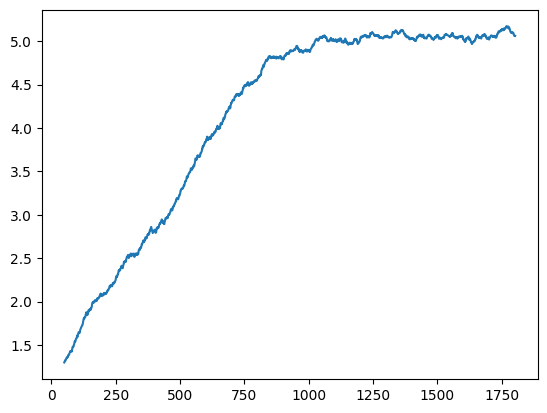

In [19]:
import matplotlib.pyplot as plt
import numpy as np

log_file = "reward.log"

with open(log_file, "r") as f:
    data = [float(line) for line in f]

# show plot of every 50 interval average
interval = 50
avg = []
for i in range(interval, len(data)):
    tmp_list = data[i-interval+1:i+1]
    avg.append(np.average(tmp_list))
plt.plot(np.arange(interval, len(data)), avg)

plt.show()

### 5. Test generated model

Now let's generate outputs by using our trained model.

In [20]:
#
# build a batch of questions
# (To use cache, we apply left-side padding.)
#

messages = [
    "What do you most want to do right now?",
    "What is the best gift to give a friend who loves the outdoors?",
    "How do you relax after something bad happens?",
]
inputs = [f"<|im_start|>user\n{m}<|im_end|>\n<|im_start|>assistant\n" for m in messages]
input_batch = tokenizer(
    inputs,
    padding=True,
    padding_side="left",
    return_tensors="pt").to(device)
input_seq_len = input_batch["input_ids"].shape[1]

#
# generate model's outputs
#

pi_new.eval()
with torch.no_grad():
    iids, mask = generate_token_by_policy(
        input_batch,
        pi_new,
        tokenizer,
        max_seq_len,
    )
iids = iids[:,input_seq_len:]
outputs = tokenizer.batch_decode(iids, skip_special_tokens=True)

#
# print results
#

for i in range(len(messages)):
    print("***** Question *****")
    print(messages[i])
    print("***** Answer *****")
    print(outputs[i])
    print("")

***** Question *****
What do you most want to do right now?
***** Answer *****
I'm so excited to dive into this new project! I've got a rad concept for our wildlife account at the fair: we're gonna put together a science lab where kids can learn about all the cool things their parents teach them about nature. It'd be EPIC!!! I got some ideas for the special exhibits and games, and I think we should also have some fun workshops for kids to share what they're learning. 🤓

I'd love to grab some coffee with you soon and chat more about it! Let me know what you think! 😊

***** Question *****
What is the best gift to give a friend who loves the outdoors?
***** Answer *****
What a wonderful thing to share with someone you love! What a wonderful thing to share with someone you love! Considering your interests, I'd be happy to help you come up with a fantastic gift. Here are a few ideas to get you started:

Maybe you'd like something really adventurous, like a giant salsa stick or a dog-friendl

## Final note - Critic-free RL methods (Appendix)

GRPO had a great influence on critic-free RL methods in LLM, resulting in many of today's critic-free RL algorithms or variants - such as, RLOO (REINFORCE Leave-One-Out), REINFORCE++, DAPO, GSPO, ...

Instead of group-level normalization, REINFORCE++ employs batch-level normalization.<br>
As you saw above, DAPO has adopted token-level loss normalization to prevent loss weight from depending on response's length. (DAPO adopts several other optimizations - such as, asymmetric clipping, rule-based rewarding (dynamic sampling), and no KL penalty. See [[Yu et al., 2025](https://arxiv.org/pdf/2503.14476)].)

Today, critic-free RL has evolved a lot.